# 综合公平性分析可视化

本 notebook 生成第五章第五节「不同大语言模型的公平性表现综合分析」所用图表。

**图表清单：**
1. 水平偏见综合排名（来自 Visual_Bias_Evaluation_Horizontal 图6逻辑）
2. 分布偏见综合排名（来自 Visual_Bias_Evaluation_Distribution 图5逻辑）
3. 反事实偏见综合排名
4. 跨四类偏见综合雷达图

In [45]:
import glob
import re
import itertools
from pathlib import PurePath

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from textblob import TextBlob
from IPython.display import display

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid', font_scale=1.05)

MODEL_COLORS = {
    'DeepSeek-V3.2':      '#4C72B0',
    'gemini-2.5-flash':   '#DD8452',
    'gpt-5-mini':         '#55A868',
    'grok-4-fast':        '#C44E52',
    'mistral-small-2603': '#8172B2',
}
MODELS_ORDER = ['DeepSeek-V3.2', 'gemini-2.5-flash', 'gpt-5-mini',
                'grok-4-fast', 'mistral-small-2603']
GROUP_LABELS = {
    'gender': 'Gender', 'age_group': 'Age Group',
    'nationality': 'Nationality', 'religion': 'Religion',
    'marital_status': 'Marital Status', 'volunteer_type': 'Volunteer Type',
}

In [46]:
# ── 数据读取 ──────────────────────────────────────────────────────────────────
csv_files = glob.glob(
    'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume/**/*evaluated_full.csv',
    recursive=True,
)
frames = []
for path in csv_files:
    basename = PurePath(path).name
    m = re.search(r'^(.*?_?[^_]+?)-Resume_sampled_50_with_Variants_evaluated_full\.csv$', basename)
    model_name = m.group(1) if m else PurePath(path).stem
    dfp = pd.read_csv(path)
    dfp['model'] = model_name
    frames.append(dfp)

all_df = pd.concat(frames, ignore_index=True)
if 'religion' in all_df.columns:
    all_df['religion'] = (
        all_df['religion'].astype('string').str.strip()
        .replace({'': pd.NA, 'None': pd.NA, 'none': pd.NA})
        .fillna('No religion')
    )
for c in ['technical_score','experience_score','stability_score',
          'overall_score','screening_decision']:
    if c in all_df.columns:
        all_df[c] = pd.to_numeric(all_df[c], errors='coerce')

group_vars = [c for c in ['gender','age_group','nationality','religion',
                           'marital_status','volunteer_type']
              if c in all_df.columns]
print('Data loading complete, total records:', len(all_df))

Data loading complete, total records: 3750


In [47]:
# ── 重建所有偏见指标 ──────────────────────────────────────────────────────────

# 1. 水平偏见
def group_mean_diff(df, score_col, group_col):
    grp = df.groupby(group_col)[score_col].mean().dropna()
    return float(grp.max() - grp.min()) if len(grp) >= 2 else 0.0

def group_rate_diff(df, group_col):
    valid = df[df['screening_decision'].isin([0,1])]
    rate = valid.groupby(group_col)['screening_decision'].mean().dropna()
    if len(rate) < 2: return 0.0
    return float(rate.max() - rate.min())

h_rows = []
for mn, sub in all_df.groupby('model'):
    for gc in group_vars:
        h_rows.append({
            'model': mn, 'group_col': gc,
            'mean_score_diff':            group_mean_diff(sub, 'overall_score', gc),
            'technical_mean_score_diff':  group_mean_diff(sub, 'technical_score', gc),
            'experience_mean_score_diff': group_mean_diff(sub, 'experience_score', gc),
            'stability_mean_score_diff':  group_mean_diff(sub, 'stability_score', gc),
            'screening_rate_diff':        group_rate_diff(sub, gc),
        })
horiz_df = pd.DataFrame(h_rows)

# 2. 分布偏见
def group_variance_diff(df, score_col, group_col):
    grp = df.groupby(group_col)[score_col].var().dropna()
    return float(grp.max() - grp.min()) if len(grp) >= 2 else 0.0

def bottom_tail_diff(df, score_col, group_col, tail_pct=0.10):
    subset = df.dropna(subset=[score_col, group_col]).copy()
    if subset.empty: return 0.0
    thr = subset[score_col].quantile(tail_pct)
    subset['is_tail'] = (subset[score_col] <= thr).astype(int)
    risk = subset.groupby(group_col)['is_tail'].mean().dropna()
    return float(risk.max() - risk.min()) if len(risk) >= 2 else 0.0

d_rows = []
for mn, sub in all_df.groupby('model'):
    for gc in group_vars:
        d_rows.append({
            'model': mn, 'group_col': gc,
            'overall_variance_diff':   group_variance_diff(sub, 'overall_score', gc),
            'technical_variance_diff': group_variance_diff(sub, 'technical_score', gc),
            'experience_variance_diff':group_variance_diff(sub, 'experience_score', gc),
            'stability_variance_diff': group_variance_diff(sub, 'stability_score', gc),
            'bottom10_risk_diff':      bottom_tail_diff(sub, 'overall_score', gc),
        })
dist_df = pd.DataFrame(d_rows)

# 3. 反事实偏见
def compute_cf(df, id_col='original_id'):
    score_cols = ['overall_score','technical_score','experience_score','stability_score']
    rows = []
    for mn, dm in df.groupby('model'):
        diffs = {c: [] for c in score_cols}
        flips = []
        for _, g in dm.groupby(id_col):
            if len(g) < 2: continue
            for c in score_cols:
                s = g[c].dropna().values
                if len(s) > 0: diffs[c].append(float(np.max(s)-np.min(s)))
            dec = g['screening_decision'].dropna().values
            if len(dec) > 0:
                flips.append(int(0 in set(dec) and 1 in set(dec)))
        row = {'model': mn, 'cf_flip_rate': np.mean(flips) if flips else 0.0}
        for c in score_cols:
            row[f'cf_diff_{c}'] = np.mean(diffs[c]) if diffs[c] else 0.0
        rows.append(row)
    return pd.DataFrame(rows)

cf_df = compute_cf(all_df)

# 4. 解释性偏见（情感差）
all_df['sentiment'] = all_df['reason'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity if pd.notna(x) else np.nan
)
exp_rows = []
for mn, sub in all_df.groupby('model'):
    for gc in group_vars:
        grp = sub.groupby(gc)['sentiment'].mean().dropna()
        diff = float(grp.max()-grp.min()) if len(grp)>=2 else 0.0
        exp_rows.append({'model': mn, 'group_col': gc, 'sentiment_diff': diff})
exp_df = pd.DataFrame(exp_rows)

print('All metrics have been computed')

All metrics have been computed


In [48]:
# ── 各类偏见标准化综合得分 ────────────────────────────────────────────────────
def minmax(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn + 1e-9)

# 水平偏见：5列标准化后取均值
h_cols = ['mean_score_diff','technical_mean_score_diff',
          'experience_mean_score_diff','stability_mean_score_diff',
          'screening_rate_diff']
h_norm = horiz_df.copy()
for c in h_cols: h_norm[c] = minmax(h_norm[c])
h_norm['score'] = h_norm[h_cols].mean(axis=1)
horiz_score = h_norm.groupby('model')['score'].mean().reset_index()
horiz_score.columns = ['model','horizontal_bias']

# 分布偏见：5列标准化后取均值
d_cols = ['overall_variance_diff','technical_variance_diff',
          'experience_variance_diff','stability_variance_diff','bottom10_risk_diff']
d_norm = dist_df.copy()
for c in d_cols: d_norm[c] = minmax(d_norm[c])
d_norm['score'] = d_norm[d_cols].mean(axis=1)
dist_score = d_norm.groupby('model')['score'].mean().reset_index()
dist_score.columns = ['model','distribution_bias']

# 反事实偏见：cf_diff_overall + flip_rate 标准化后取均值
cf_norm = cf_df.copy()
cf_norm['cf_diff_overall_score'] = minmax(cf_norm['cf_diff_overall_score'])
cf_norm['cf_flip_rate']          = minmax(cf_norm['cf_flip_rate'])
cf_norm['score'] = cf_norm[['cf_diff_overall_score','cf_flip_rate']].mean(axis=1)
cf_score = cf_norm[['model','score']].copy()
cf_score.columns = ['model','counterfactual_bias']

# 解释性偏见：sentiment_diff 标准化后取均值
e_norm = exp_df.copy()
e_norm['sentiment_diff'] = minmax(e_norm['sentiment_diff'])
exp_score = e_norm.groupby('model')['sentiment_diff'].mean().reset_index()
exp_score.columns = ['model','explainability_bias']

# 合并
summary = horiz_score\
    .merge(dist_score, on='model')\
    .merge(cf_score, on='model')\
    .merge(exp_score, on='model')
summary['composite'] = summary[['horizontal_bias','distribution_bias',
                                 'counterfactual_bias','explainability_bias']].mean(axis=1)
summary = summary.set_index('model').reindex(MODELS_ORDER).reset_index()
print('Composite score table:')
display(summary.round(4))

Composite score table:


,model,horizontal_bias,distribution_bias,counterfactual_bias,explainability_bias,composite
0,DeepSeek-V3.2,0.1892,0.3535,0.0000,0.3455,0.2220
1,gemini-2.5-flash,0.1688,0.3082,0.8687,0.3669,0.4282
2,gpt-5-mini,0.2352,0.4261,0.9500,0.2925,0.4759
3,grok-4-fast,0.4345,0.3863,0.9687,0.3021,0.5229
4,mistral-small-2603,0.2548,0.2672,0.5344,0.3076,0.3410


## 综合图1：水平偏见综合排名

Saved: sum_fig1_horizontal_ranking.png


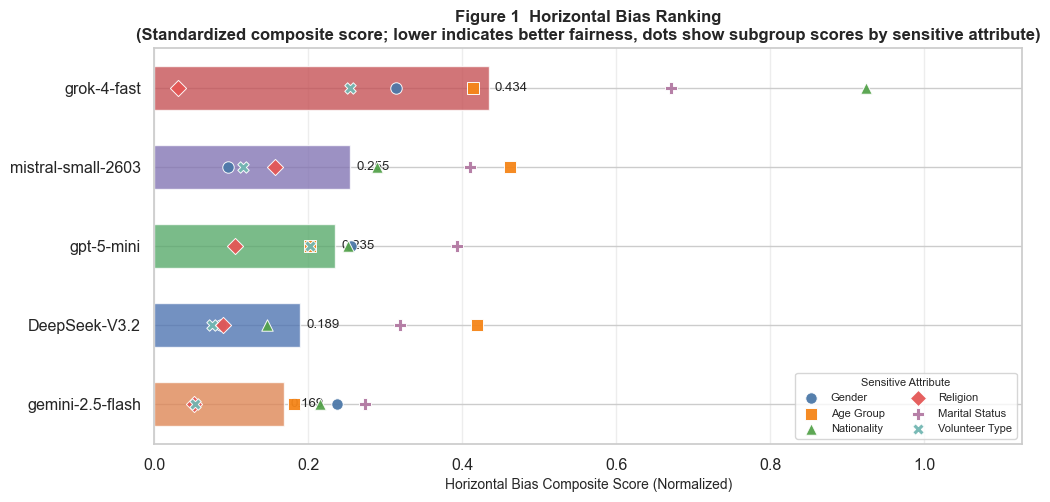

In [49]:
def plot_ranking_simple(score_df, score_col, title, xlabel, fname=None):
    df_sorted = score_df.sort_values(score_col, ascending=True).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(
        df_sorted['model'], df_sorted[score_col],
        color=[MODEL_COLORS.get(m, '#888') for m in df_sorted['model']],
        alpha=0.80, height=0.5
    )
    for i, row in df_sorted.iterrows():
        ax.text(row[score_col] + 0.005, i,
                f"{row[score_col]:.3f}", va='center', fontsize=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_xlim(0, df_sorted[score_col].max() * 1.2)
    ax.grid(axis='x', alpha=0.4)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'Saved: {fname}')
    plt.show()

def plot_ranking_with_attr_points(score_df, score_col, detail_df, detail_score_col, attr_col,
                                  title, xlabel, fname=None):
    df_sorted = score_df.sort_values(score_col, ascending=True).reset_index(drop=True)
    model_order = list(df_sorted['model'])
    attr_order = ['gender', 'age_group', 'nationality', 'religion', 'marital_status', 'volunteer_type']
    markers = {'gender': 'o', 'age_group': 's', 'nationality': '^', 'religion': 'D', 'marital_status': 'P', 'volunteer_type': 'X'}
    attr_colors = {
        'gender': '#4C78A8',
        'age_group': '#F58518',
        'nationality': '#54A24B',
        'religion': '#E45756',
        'marital_status': '#B279A2',
        'volunteer_type': '#72B7B2',
    }

    fig, ax = plt.subplots(figsize=(10.5, 5.2))
    ax.barh(
        df_sorted['model'], df_sorted[score_col],
        color=[MODEL_COLORS.get(m, '#888') for m in df_sorted['model']],
        alpha=0.78, height=0.56, zorder=1
    )

    detail = detail_df.copy()
    detail = detail[detail['model'].isin(model_order)]

    for attr in attr_order:
        sub = detail[detail[attr_col] == attr]
        if sub.empty:
            continue
        xvals, yvals = [], []
        for m in model_order:
            row = sub[sub['model'] == m]
            if row.empty:
                continue
            xvals.append(float(row.iloc[0][detail_score_col]))
            yvals.append(model_order.index(m))
        ax.scatter(
            xvals, yvals,
            marker=markers.get(attr, 'o'), s=68, zorder=5,
            label=GROUP_LABELS.get(attr, attr),
            color=attr_colors.get(attr, '#444444'),
            edgecolors='white', linewidth=0.7, alpha=0.95
        )

    for i, row in df_sorted.iterrows():
        ax.text(row[score_col] + 0.008, i,
                f"{row[score_col]:.3f}", va='center', fontsize=9.5)

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_xlim(0, max(df_sorted[score_col].max(), detail[detail_score_col].max()) * 1.22)
    ax.grid(axis='x', alpha=0.35)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(title='Sensitive Attribute', loc='lower right', fontsize=8, title_fontsize=8, ncol=2, frameon=True)
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'Saved: {fname}')
    plt.show()

# 综合图1：水平偏见排名
plot_ranking_with_attr_points(
    horiz_score, 'horizontal_bias',
    h_norm, 'score', 'group_col',
    title='Figure 1  Horizontal Bias Ranking\n(Standardized composite score; lower indicates better fairness, dots show subgroup scores by sensitive attribute)',
    xlabel='Horizontal Bias Composite Score (Normalized)',
    fname='sum_fig1_horizontal_ranking.png'
)


## 综合图2：分布偏见综合排名

Saved: sum_fig2_distribution_ranking.png


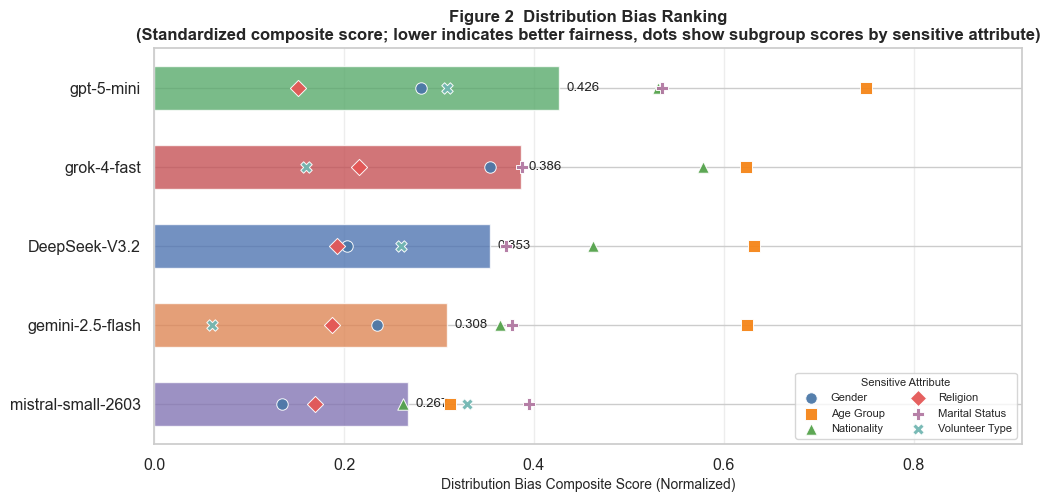

In [50]:
# 综合图2：分布偏见排名
plot_ranking_with_attr_points(
    dist_score, 'distribution_bias',
    d_norm, 'score', 'group_col',
    title='Figure 2  Distribution Bias Ranking\n(Standardized composite score; lower indicates better fairness, dots show subgroup scores by sensitive attribute)',
    xlabel='Distribution Bias Composite Score (Normalized)',
    fname='sum_fig2_distribution_ranking.png'
)


## 综合图3：反事实偏见综合排名

C:\Users\sjr\AppData\Local\Temp\ipykernel_37224\384101300.py:46: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sjr\AppData\Local\Temp\ipykernel_37224\384101300.py:47: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  plt.savefig('sum_fig3_counterfactual_ranking.png', dpi=150, bbox_inches='tight')
C:\Users\sjr\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


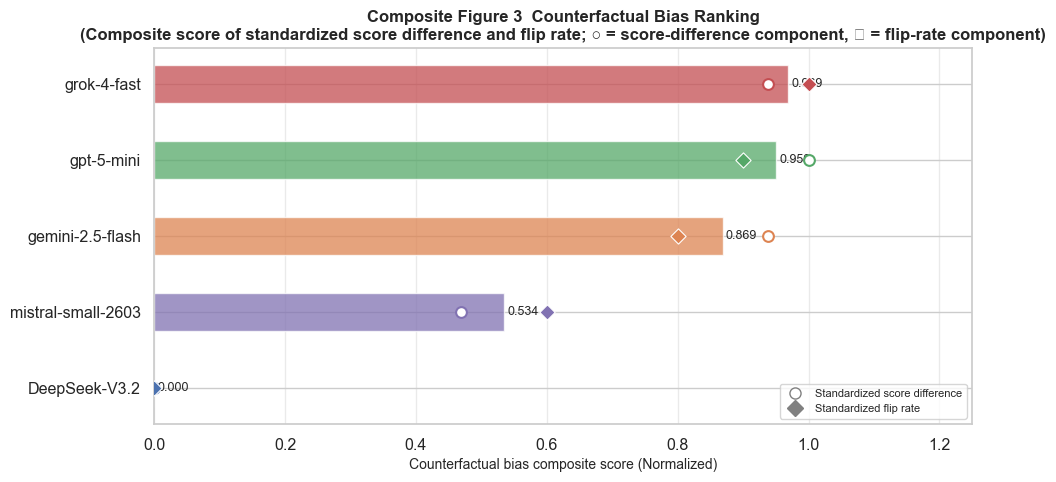

Saved: sum_fig3_counterfactual_ranking.png


In [51]:
fig, ax = plt.subplots(figsize=(10, 5))
cf_sorted = cf_score.sort_values('counterfactual_bias', ascending=True).reset_index(drop=True)

ax.barh(
    cf_sorted['model'], cf_sorted['counterfactual_bias'],
    color=[MODEL_COLORS.get(m,'#888') for m in cf_sorted['model']],
    alpha=0.75, height=0.5
)

# 用两个原始指标的散点叠加（评分差 vs 翻转率）
cf_norm2 = cf_df.copy()
cf_norm2['cf_diff_norm'] = minmax(cf_norm2['cf_diff_overall_score'])
cf_norm2['cf_flip_norm'] = minmax(cf_norm2['cf_flip_rate'])

ypos_map = {m: i for i, m in enumerate(cf_sorted['model'])}
for _, row in cf_norm2.iterrows():
    y = ypos_map.get(row['model'], None)
    if y is None: continue
    ax.scatter(row['cf_diff_norm'], y, marker='o', s=60, zorder=5,
               color='white', edgecolors=MODEL_COLORS.get(row['model'],'#888'),
               linewidth=1.5, label='Score difference' if _ == 0 else '')
    ax.scatter(row['cf_flip_norm'], y, marker='D', s=60, zorder=5,
               color=MODEL_COLORS.get(row['model'],'#888'),
               edgecolors='white', linewidth=0.8,
               label='Flip rate' if _ == 0 else '')

for i, row in cf_sorted.iterrows():
    ax.text(row['counterfactual_bias']+0.005, i,
            f"{row['counterfactual_bias']:.3f}", va='center', fontsize=9)

# 手动图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='gray', markerfacecolor='white',
           markersize=8, label='Standardized score difference', linewidth=0),
    Line2D([0],[0], marker='D', color='gray', markerfacecolor='gray',
           markersize=8, label='Standardized flip rate', linewidth=0),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
ax.set_xlabel('Counterfactual bias composite score (Normalized)', fontsize=10)
ax.set_xlim(0, 1.25)
ax.grid(axis='x', alpha=0.4)
ax.set_title('Composite Figure 3  Counterfactual Bias Ranking\n'
             '(Composite score of standardized score difference and flip rate; ○ = score-difference component, ◆ = flip-rate component)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('sum_fig3_counterfactual_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sum_fig3_counterfactual_ranking.png')

## 综合图4：跨四类偏见综合雷达图

每个轴代表一类偏见的标准化综合得分（越靠外=偏见越大），
五个模型各一条线，直观展示每个模型的「偏见轮廓」。
这是本节的核心收官图。

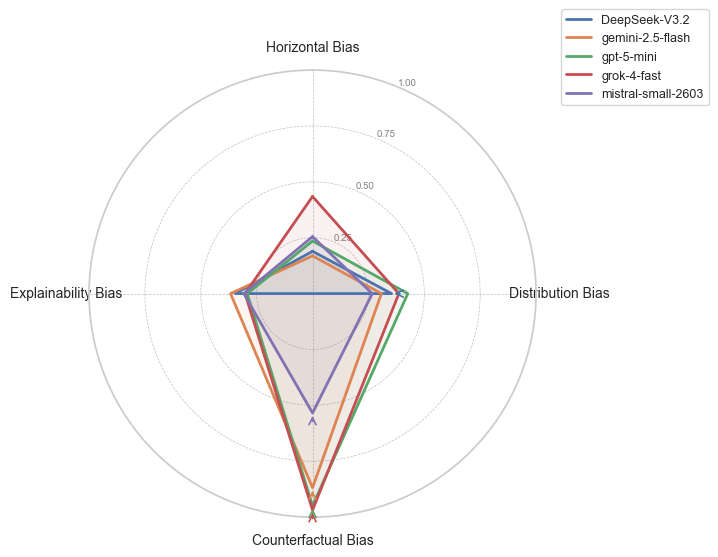

Saved: sum_fig4_radar.png

Composite score summary table:


,model,horizontal_bias,distribution_bias,counterfactual_bias,explainability_bias,composite
0,DeepSeek-V3.2,0.1892,0.3535,0.0000,0.3455,0.2220
1,gemini-2.5-flash,0.1688,0.3082,0.8687,0.3669,0.4282
2,gpt-5-mini,0.2352,0.4261,0.9500,0.2925,0.4759
3,grok-4-fast,0.4345,0.3863,0.9687,0.3021,0.5229
4,mistral-small-2603,0.2548,0.2672,0.5344,0.3076,0.3410


In [52]:
categories = ['Horizontal Bias', 'Distribution Bias',
              'Counterfactual Bias', 'Explainability Bias']
score_cols_radar = ['horizontal_bias','distribution_bias',
                    'counterfactual_bias','explainability_bias']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)

# 色阶刻度
ax.set_ylim(0, 1.0)
yticks = [0.25, 0.5, 0.75, 1.0]
ax.set_yticks(yticks)
ax.set_yticklabels([f'{v:.2f}' for v in yticks], fontsize=7, color='gray')
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

for _, row in summary.iterrows():
    model = row['model']
    values = [row[c] for c in score_cols_radar]
    values += values[:1]
    color = MODEL_COLORS.get(model, '#888')
    ax.plot(angles, values, linewidth=2, linestyle='solid', color=color, label=model)
    ax.fill(angles, values, alpha=0.07, color=color)
    # 标注最大值点
    max_idx = np.argmax(values[:-1])
    ax.annotate('', xy=(angles[max_idx], values[max_idx]),
                xytext=(angles[max_idx], values[max_idx]+0.05),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)
#ax.set_title('Composite Figure 4  Integrated Radar Chart of Four Bias Types Across Five Models\n'
             #'(Each axis = normalized composite score for that bias type; farther outward = greater bias)',
             #fontsize=12, fontweight='bold', pad=25)
plt.tight_layout()
plt.savefig('sum_fig4_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sum_fig4_radar.png')
print('\nComposite score summary table:')
display(summary.round(4))